# Import Libs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Dataset

In [2]:
train_df = pd.read_csv("/kaggle/input/spaceship-titanic/train.csv")
test_df  = pd.read_csv("/kaggle/input/spaceship-titanic/test.csv")

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


# EDA

In [3]:
train_df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [4]:
train_df.head(20)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


In [5]:
train_df.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64

<Axes: xlabel='CryoSleep', ylabel='HomePlanet'>

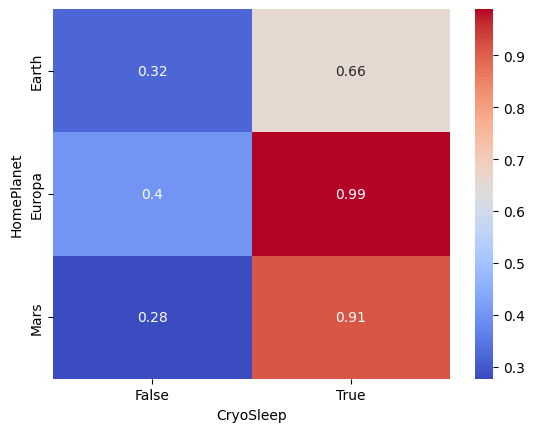

In [6]:
pivot = train_df.pivot_table(index = "HomePlanet" , columns = "CryoSleep" , values = "Transported" , aggfunc  = "mean")
sns.heatmap (pivot , annot = True , cmap = "coolwarm")

In [7]:
#passengerId 3 özniteliğe bölünüyo
#cabin 3 özniteliğe bölünüyo
#toplam harcama eklencek
train_df.drop("Name" , inplace = True  ,axis = 1)
train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True


<Axes: xlabel='VIP', ylabel='Destination'>

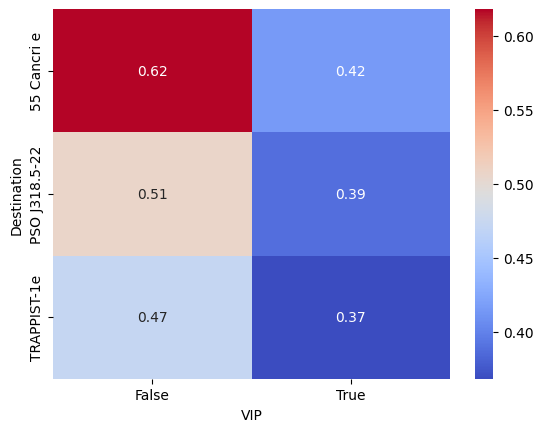

In [8]:
pivot2 = train_df.pivot_table(index = "Destination" , columns = "VIP" , values = "Transported" , aggfunc  = "mean")
sns.heatmap(pivot2 , annot = True , cmap = "coolwarm")

# Outlier

Text(0.5, 1.0, 'Yaş Harcama İlişkisi')

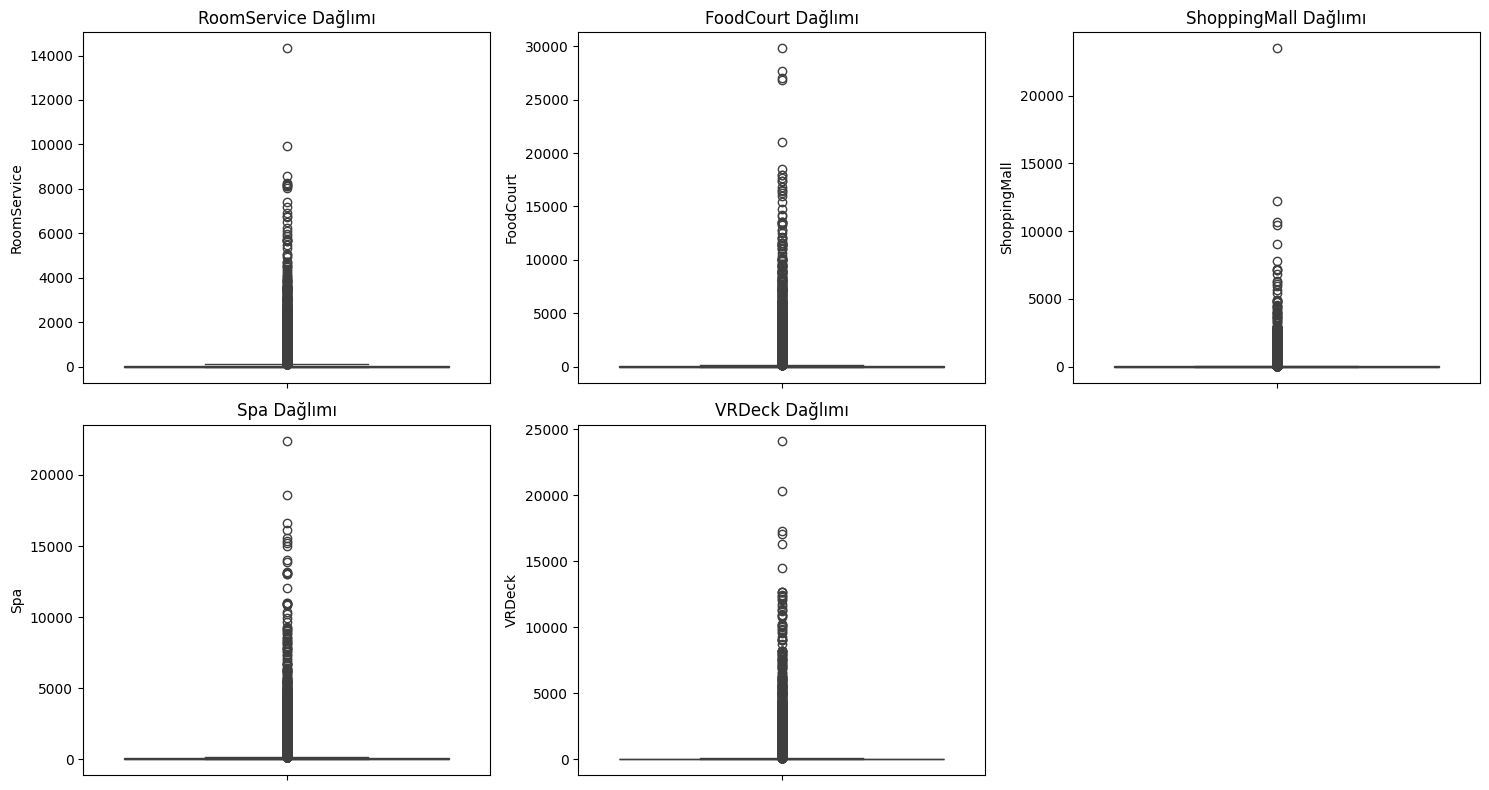

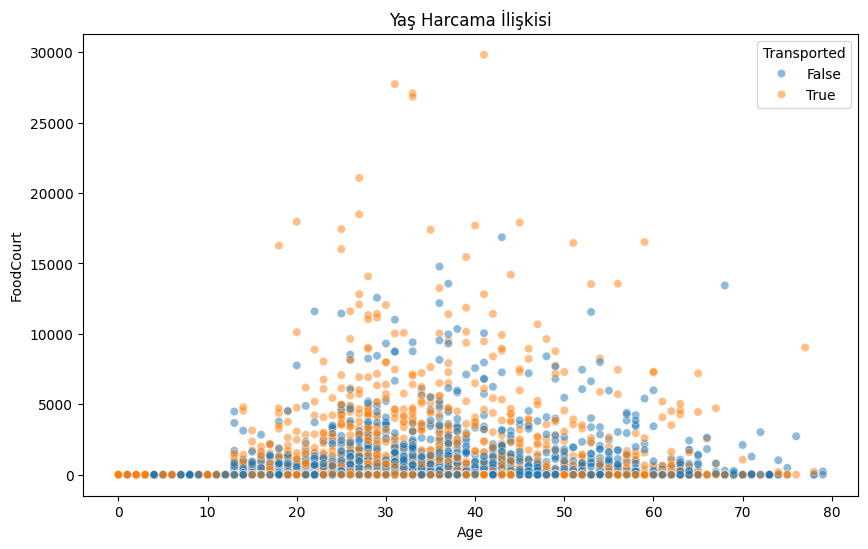

In [9]:
spend_feature = ["RoomService" , "FoodCourt","ShoppingMall" , "Spa" , "VRDeck" ]
plt.figure(figsize=(15,8))
for i , col in enumerate(spend_feature):
    plt.subplot(2,3,i+1)
    sns.boxplot(y= train_df[col])
    plt.title(f"{col} Dağlımı")

plt.tight_layout()

plt.figure(figsize=(10,6))
sns.scatterplot(data = train_df , x="Age" , y = "FoodCourt" ,hue = "Transported" , alpha = 0.5)
plt.title("Yaş Harcama İlişkisi")

## IQR

In [10]:
def iqr_analiz(carpan):
    print(f"---------------------------------------- {carpan} ÇARPANIYLA ANALİZ ----------------------------------------" )
    for col in spend_feature:
        Q1 = train_df[col].quantile(0.25)
        Q3 = train_df[col].quantile(0.75)
        IQR = Q3 - Q1

        ust_sinir = Q3 + (carpan * IQR)
        alt_sinir = Q1 - (carpan * IQR)

        outlier_sayisi = len(train_df[(train_df[col] > ust_sinir ) |(train_df[col] < alt_sinir) ])
        
        print(f"-----{col} Analizi-----")
        print(f"Üst Sınır: {ust_sinir}")
        print(f"Alt Sınır: {alt_sinir}")
        print(f"Outlier Sayısı: {outlier_sayisi}")
        print(f"Değerler Toplamı: {train_df[col].value_counts()}")
        print(f"Unique Değerler: {train_df[col].nunique()}")
iqr_analiz(30)
iqr_analiz(1.5)


        

---------------------------------------- 30 ÇARPANIYLA ANALİZ ----------------------------------------
-----RoomService Analizi-----
Üst Sınır: 1457.0
Alt Sınır: -1410.0
Outlier Sayısı: 346
Değerler Toplamı: RoomService
0.0       5577
1.0        117
2.0         79
3.0         61
4.0         47
          ... 
6899.0       1
1954.0       1
3146.0       1
1297.0       1
2555.0       1
Name: count, Length: 1273, dtype: int64
Unique Değerler: 1273
-----FoodCourt Analizi-----
Üst Sınır: 2356.0
Alt Sınır: -2280.0
Outlier Sayısı: 482
Değerler Toplamı: FoodCourt
0.0       5456
1.0        116
2.0         75
4.0         53
3.0         53
          ... 
2053.0       1
432.0        1
5151.0       1
3456.0       1
1652.0       1
Name: count, Length: 1507, dtype: int64
Unique Değerler: 1507
-----ShoppingMall Analizi-----
Üst Sınır: 837.0
Alt Sınır: -810.0
Outlier Sayısı: 536
Değerler Toplamı: ShoppingMall
0.0        5587
1.0         153
2.0          80
3.0          59
4.0          45
           ... 
